Kernel 3x3 (Box blur):
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]

Đang tính I1 (kernel 3x3, padding=1)...
Kích thước I1: (789, 719)

Đang tính I2 (kernel 5x5, padding=2)...
Kích thước I2: (789, 719)

Đang tính I3 (kernel 7x7, padding=3, stride=2)...
Kích thước I3: (395, 360)
(I3 nhỏ hơn vì stride=2 làm ảnh output bị thu nhỏ một nửa)

Đang tính I4 (lọc trung vị I3, neighbors 3x3)...
Kích thước I4: (395, 360)

Đang tính I5 (lọc trung vị I1, neighbors 5x5)...
Kích thước I5: (789, 719)

Kích thước I4 trước khi chỉnh: (395, 360)
Kích thước I5 trước khi chỉnh: (789, 719)
Kích thước I4 sau khi chỉnh: (789, 719)
Kích thước I5 sau khi chỉnh: (789, 719)
Kích thước I6: (789, 719)

Đã lưu hình kết quả vào ket_qua_cau2.png


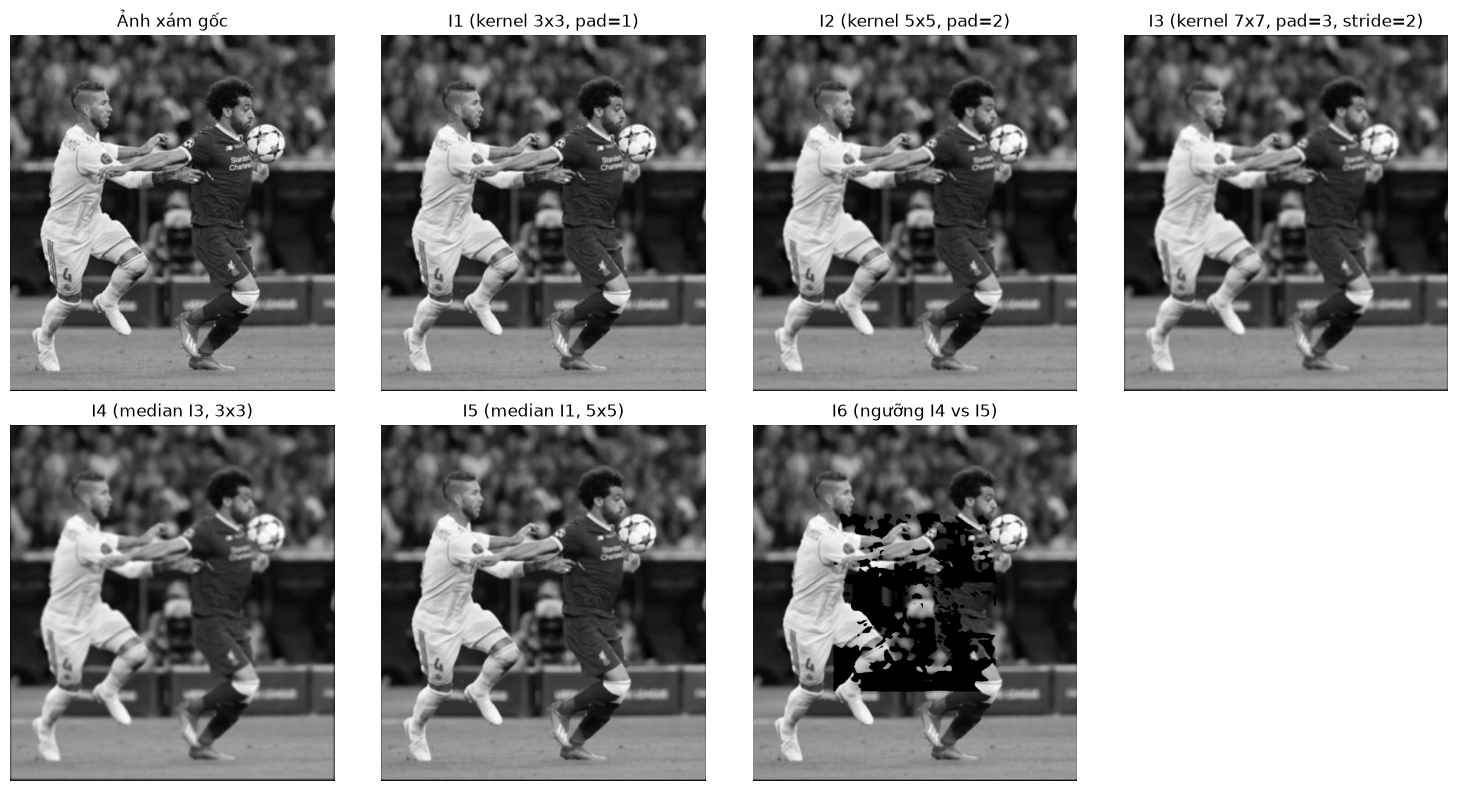


====== THÔNG TIN KIỂM TRA ======
Ảnh xám gốc      : (789, 719) min = 0 max = 255
I1 (3x3, pad=1)  : (789, 719) min = 0 max = 252
I2 (5x5, pad=2)  : (789, 719) min = 3 max = 250
I3 (7x7, pad=3, stride=2): (395, 360) min = 3 max = 249
I4 (median I3, 3x3): (395, 360) min = 0 max = 248
I5 (median I1, 5x5): (789, 719) min = 0 max = 250
I6 (ngưỡng)       : (789, 719) min = 0 max = 250


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 0. Đọc ảnh màu
# =========================
file_name = "anh1.jpg"
img = cv2.imread(file_name)

if img is None:
    raise FileNotFoundError("Không tìm thấy ảnh")

h, w, c = img.shape

# =========================
# 1. Chuyển ảnh màu sang ảnh xám thủ công
# OpenCV đọc ảnh theo BGR
# Gray = 0.299R + 0.587G + 0.114B
# =========================
gray = np.zeros((h, w), dtype=np.uint8)

for i in range(h):
    for j in range(w):
        B = img[i, j, 0]
        G = img[i, j, 1]
        R = img[i, j, 2]

        gray_value = 0.299 * R + 0.587 * G + 0.114 * B
        gray[i, j] = int(round(gray_value))


# =========================================================
# HÀM 1: THÊM PADDING (viền 0) QUANH ẢNH
# Mục đích: khi kernel trượt tới sát biên ảnh, nó vẫn có đủ
# pixel xung quanh để tính toán (không bị tràn ra ngoài).
# pad = số lớp viền 0 thêm vào mỗi cạnh
# =========================================================
def add_padding(image, pad):
    old_h, old_w = image.shape
    new_h = old_h + 2 * pad
    new_w = old_w + 2 * pad

    padded = np.zeros((new_h, new_w), dtype=np.float64)

    # copy ảnh gốc vào giữa, phần viền xung quanh giữ giá trị 0
    for i in range(old_h):
        for j in range(old_w):
            padded[i + pad, j + pad] = image[i, j]

    return padded


# =========================================================
# HÀM 2: PHÉP TÍCH CHẬP (CONVOLUTION) THỦ CÔNG
# Tham số:
#   image      : ảnh xám đầu vào (2 chiều)
#   kernel     : ma trận trọng số (vd 3x3, 5x5, 7x7)
#   pad        : số lớp padding thêm vào ảnh
#   stride     : bước nhảy khi trượt kernel (mặc định = 1)
#
# Công thức tích chập tại 1 điểm (x, y):
#   output(x,y) = sum( kernel(a,b) * image(x+a, y+b) )
#                 với a, b chạy khắp kernel
# =========================================================
def convolution(image, kernel, pad, stride=1):
    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Bước 1: thêm padding cho ảnh gốc
    padded = add_padding(image, pad)

    # Bước 2: tính kích thước ảnh output theo công thức chuẩn
    # out_size = (kich_thuoc_anh + 2*pad - kich_thuoc_kernel) / stride + 1
    out_h = (img_h + 2 * pad - k_h) // stride + 1
    out_w = (img_w + 2 * pad - k_w) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float64)

    # Bước 3: trượt kernel khắp ảnh đã padding
    for out_i in range(out_h):
        for out_j in range(out_w):
            # vị trí bắt đầu (góc trên-trái) của vùng ảnh đang xét
            start_i = out_i * stride
            start_j = out_j * stride

            # lấy ra vùng ảnh con có cùng kích thước với kernel
            region = padded[start_i:start_i + k_h, start_j:start_j + k_w]

            # nhân từng phần tử với kernel rồi cộng lại (tích chập)
            value = 0.0
            for a in range(k_h):
                for b in range(k_w):
                    value += kernel[a, b] * region[a, b]

            output[out_i, out_j] = value

    # Bước 4: ép giá trị về khoảng [0, 255] và kiểu uint8 (ảnh hợp lệ)
    output = np.clip(output, 0, 255)
    output = output.astype(np.uint8)

    return output


# =========================================================
# 2. TẠO CÁC KERNEL BOX BLUR (TRUNG BÌNH CỘNG)
# Box blur: mỗi phần tử kernel = 1 / (kich_thuoc * kich_thuoc)
# Ý nghĩa: giá trị pixel mới = trung bình cộng các pixel lân cận
# => làm mờ ảnh, giảm nhiễu
# =========================================================
kernel_3x3 = np.ones((3, 3), dtype=np.float64) / (3 * 3)
kernel_5x5 = np.ones((5, 5), dtype=np.float64) / (5 * 5)
kernel_7x7 = np.ones((7, 7), dtype=np.float64) / (7 * 7)

print("Kernel 3x3 (Box blur):")
print(kernel_3x3)


# =========================================================
# 3. THỰC HIỆN TÍCH CHẬP THEO YÊU CẦU ĐỀ BÀI
#    I1: kernel 3x3, padding = 1, stride = 1
#    I2: kernel 5x5, padding = 2, stride = 1
#    I3: kernel 7x7, padding = 3, stride = 2
# =========================================================
print("\nĐang tính I1 (kernel 3x3, padding=1)...")
I1 = convolution(gray, kernel_3x3, pad=1, stride=1)
print("Kích thước I1:", I1.shape)

print("\nĐang tính I2 (kernel 5x5, padding=2)...")
I2 = convolution(gray, kernel_5x5, pad=2, stride=1)
print("Kích thước I2:", I2.shape)

print("\nĐang tính I3 (kernel 7x7, padding=3, stride=2)...")
I3 = convolution(gray, kernel_7x7, pad=3, stride=2)
print("Kích thước I3:", I3.shape)
print("(I3 nhỏ hơn vì stride=2 làm ảnh output bị thu nhỏ một nửa)")


# =========================================================
# HÀM 3: LỌC TRUNG VỊ (MEDIAN FILTER) THỦ CÔNG
# Ý tưởng: tại mỗi pixel, lấy ra tất cả pixel trong vùng lân cận
# (vd 3x3 hoặc 5x5), SẮP XẾP chúng tăng dần, rồi lấy giá trị
# Ở GIỮA (trung vị / median) làm giá trị pixel mới.
# Khác Box blur: median filter không lấy trung bình mà lấy trung vị
# => loại nhiễu muối-tiêu (salt-pepper) tốt hơn, giữ cạnh rõ hơn.
# =========================================================
def median_filter(image, ksize):
    img_h, img_w = image.shape
    pad = ksize // 2  # số lớp padding cần thêm để vùng lân cận đủ pixel

    padded = add_padding(image, pad)

    output = np.zeros((img_h, img_w), dtype=np.uint8)

    for i in range(img_h):
        for j in range(img_w):
            # lấy vùng lân cận ksize x ksize quanh pixel (i, j)
            region = padded[i:i + ksize, j:j + ksize]

            # chuyển vùng 2D thành danh sách 1D rồi sắp xếp tăng dần
            values = []
            for a in range(ksize):
                for b in range(ksize):
                    values.append(region[a, b])
            values.sort()

            # lấy giá trị ở chính giữa danh sách đã sắp xếp = trung vị
            median_value = values[len(values) // 2]

            output[i, j] = int(median_value)

    return output


# =========================================================
# 4. TÌM I4: LỌC TRUNG VỊ ẢNH I3 VỚI LÂN CẬN 3x3
# =========================================================
print("\nĐang tính I4 (lọc trung vị I3, neighbors 3x3)...")
I4 = median_filter(I3, ksize=3)
print("Kích thước I4:", I4.shape)

# =========================================================
# 5. TÌM I5: LỌC TRUNG VỊ ẢNH I1 VỚI LÂN CẬN 5x5
# =========================================================
print("\nĐang tính I5 (lọc trung vị I1, neighbors 5x5)...")
I5 = median_filter(I1, ksize=5)
print("Kích thước I5:", I5.shape)


# =========================================================
# HÀM 4: ĐƯA 2 ẢNH VỀ CÙNG KÍCH THƯỚC BẰNG CÁCH THÊM PADDING
# Vì I4 (từ I3, có stride=2) sẽ nhỏ hơn I5 (từ I1, stride=1)
# nên trước khi so sánh pixel-by-pixel, ta cần "phóng" ảnh nhỏ hơn
# lên cùng kích thước ảnh lớn hơn bằng cách thêm viền 0 vào xung quanh.
# =========================================================
def make_same_size(imageA, imageB):
    hA, wA = imageA.shape
    hB, wB = imageB.shape

    if (hA, wA) == (hB, wB):
        # đã cùng kích thước, không cần làm gì
        return imageA, imageB

    # xác định kích thước lớn nhất giữa 2 ảnh
    target_h = max(hA, hB)
    target_w = max(wA, wB)

    # hàm phụ: đặt ảnh nhỏ vào giữa 1 nền 0 có kích thước target
    def pad_to_target(image, target_h, target_w):
        old_h, old_w = image.shape
        new_img = np.zeros((target_h, target_w), dtype=np.uint8)

        # tính lề trên/trái để đặt ảnh gốc vào CHÍNH GIỮA nền mới
        offset_h = (target_h - old_h) // 2
        offset_w = (target_w - old_w) // 2

        for i in range(old_h):
            for j in range(old_w):
                new_img[i + offset_h, j + offset_w] = image[i, j]

        return new_img

    imageA_new = pad_to_target(imageA, target_h, target_w)
    imageB_new = pad_to_target(imageB, target_h, target_w)

    return imageA_new, imageB_new


# =========================================================
# 6. XÂY DỰNG I6 BẰNG PHÉP LẤY NGƯỠNG
# Quy tắc:
#   Nếu I4(x,y) > I5(x,y)  ->  I6(x,y) = 0
#   Ngược lại              ->  I6(x,y) = I5(x,y)
# Trước tiên phải đưa I4, I5 về cùng kích thước.
# =========================================================
print("\nKích thước I4 trước khi chỉnh:", I4.shape)
print("Kích thước I5 trước khi chỉnh:", I5.shape)

I4_resized, I5_resized = make_same_size(I4, I5)

print("Kích thước I4 sau khi chỉnh:", I4_resized.shape)
print("Kích thước I5 sau khi chỉnh:", I5_resized.shape)

new_h, new_w = I4_resized.shape
I6 = np.zeros((new_h, new_w), dtype=np.uint8)

for i in range(new_h):
    for j in range(new_w):
        if I4_resized[i, j] > I5_resized[i, j]:
            I6[i, j] = 0
        else:
            I6[i, j] = I5_resized[i, j]

print("Kích thước I6:", I6.shape)


# =========================================================
# 7. HIỂN THỊ TẤT CẢ KẾT QUẢ
# =========================================================
plt.figure(figsize=(15, 8))

plt.subplot(2, 4, 1)
plt.imshow(gray, cmap="gray")
plt.title("Ảnh xám gốc")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(I1, cmap="gray")
plt.title("I1 (kernel 3x3, pad=1)")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(I2, cmap="gray")
plt.title("I2 (kernel 5x5, pad=2)")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(I3, cmap="gray")
plt.title("I3 (kernel 7x7, pad=3, stride=2)")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(I4, cmap="gray")
plt.title("I4 (median I3, 3x3)")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(I5, cmap="gray")
plt.title("I5 (median I1, 5x5)")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(I6, cmap="gray")
plt.title("I6 (ngưỡng I4 vs I5)")
plt.axis("off")

plt.tight_layout()
plt.savefig("ket_qua_cau2.png", dpi=100)
print("\nĐã lưu hình kết quả vào ket_qua_cau2.png")
plt.show()


# =========================================================
# 8. IN THÔNG TIN KIỂM TRA
# =========================================================
print("\n====== THÔNG TIN KIỂM TRA ======")
print("Ảnh xám gốc      :", gray.shape, "min =", gray.min(), "max =", gray.max())
print("I1 (3x3, pad=1)  :", I1.shape, "min =", I1.min(), "max =", I1.max())
print("I2 (5x5, pad=2)  :", I2.shape, "min =", I2.min(), "max =", I2.max())
print("I3 (7x7, pad=3, stride=2):", I3.shape, "min =", I3.min(), "max =", I3.max())
print("I4 (median I3, 3x3):", I4.shape, "min =", I4.min(), "max =", I4.max())
print("I5 (median I1, 5x5):", I5.shape, "min =", I5.min(), "max =", I5.max())
print("I6 (ngưỡng)       :", I6.shape, "min =", I6.min(), "max =", I6.max())